In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import warnings

warnings.filterwarnings('ignore')
print("Libraries imported successfully!")


Libraries imported successfully!


In [13]:
# Load dataset
df = pd.read_csv('archive/Restaurant reviews.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (10000, 8)

Columns: ['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time', 'Pictures', '7514']

First 5 rows:


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,7514
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0,2447.0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0,NaN
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0,NaN
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0,NaN
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0,NaN


In [15]:
# Kiểm tra thông tin dataset
print("Dataset Info:")
print(f"- Total rows: {len(df)}")
print(f"- Missing values:\n{df.isnull().sum()}")
print(f"\n- Rating distribution:\n{df['Rating'].value_counts().sort_index()}")
print(f"\n- Data types:\n{df.dtypes}")

Dataset Info:
- Total rows: 10000
- Missing values:
Restaurant       0
Reviewer        38
Review          45
Rating          38
Metadata        38
Time            38
Pictures         0
7514          9999
dtype: int64

- Rating distribution:
Rating
1       1735
1.5        9
2        684
2.5       19
3       1193
3.5       47
4       2373
4.5       69
5       3832
Like       1
Name: count, dtype: int64

- Data types:
Restaurant     object
Reviewer       object
Review         object
Rating         object
Metadata       object
Time           object
Pictures        int64
7514          float64
dtype: object


In [45]:
import re

def clean_text(text):
    """
    Xử lý văn bản thô
    - Chuyển về chữ thường
    - Loại bỏ ký tự đặc biệt và số
    - Loại bỏ khoảng trắng thừa
    """
    text = str(text)
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# =========================
# CLEAN RATING
# =========================

# 1. Bỏ rating dạng string "Like"
df = df[df['Rating'] != 'Like']

# 2. Convert rating về float
df['Rating'] = df['Rating'].astype(float)

# 3. Làm tròn rating về số nguyên gần nhất (1–5)
df['Rating'] = df['Rating'].round().astype(int)

# 4. Đảm bảo rating nằm trong [1, 5]
df = df[df['Rating'].between(1, 5)]

print("✓ Đã làm sạch & làm tròn Rating")
print(df['Rating'].value_counts().sort_index())


# =========================
# CLEAN TEXT
# =========================

print("\nĐang xử lý văn bản thô...")
df['text_clean'] = df['Review'].apply(clean_text)


# =========================
# HIỂN THỊ VÍ DỤ
# =========================

print("\nVí dụ văn bản sau khi xử lý:")
for i in range(3):
    print(f"\n--- Example {i+1} ---")
    print(f"Original: {df['Review'].iloc[i][:100]}...")
    print(f"Cleaned:  {df['text_clean'].iloc[i][:100]}...")


✓ Đã làm sạch & làm tròn Rating
Rating
1    1735
2     684
3    1193
4    2373
5    3832
Name: count, dtype: int64

Đang xử lý văn bản thô...

Ví dụ văn bản sau khi xử lý:

--- Example 1 ---
Original: The ambience was good, food was quite good . had Saturday lunch , which was cost effective .
Good pl...
Cleaned:  the ambience was good food was quite good had saturday lunch which was cost effective good place for...

--- Example 2 ---
Original: Ambience is too good for a pleasant evening. Service is very prompt. Food is good. Over all a good e...
Cleaned:  ambience is too good for a pleasant evening service is very prompt food is good over all a good expe...

--- Example 3 ---
Original: A must try.. great food great ambience. Thnx for the service by Pradeep and Subroto. My personal rec...
Cleaned:  a must try great food great ambience thnx for the service by pradeep and subroto my personal recomme...


In [17]:
# Khởi tạo TF-IDF Vectorizer
# TfidfVectorizer tự động thực hiện:
# 1. Tokenization (tách từ)
# 2. Loại bỏ stopwords (stop_words='english')
# 3. Tính toán TF-IDF scores

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,        # Giới hạn 5000 từ quan trọng nhất
    stop_words='english',     # Loại bỏ stopwords tiếng Anh từ sklearn
    ngram_range=(1, 2),       # Sử dụng unigrams và bigrams
    min_df=2,                 # Từ phải xuất hiện ít nhất 2 lần
    max_df=0.8,               # Từ không xuất hiện quá 80% documents
    lowercase=True,           # Đã lowercase rồi nhưng đảm bảo thêm
    strip_accents='unicode'   # Loại bỏ dấu
)

print("Đang tạo TF-IDF features...")
print("- Tokenization (tách từ)")
print("- Loại bỏ stopwords")
print("- Tính toán TF-IDF scores\n")

# Fit và transform
X_tfidf = tfidf_vectorizer.fit_transform(df['text_clean'])

print(f"✓ TF-IDF matrix shape: {X_tfidf.shape}")
print(f"✓ Số documents: {X_tfidf.shape[0]}")
print(f"✓ Số features (từ sau khi loại stopwords): {X_tfidf.shape[1]}")
print(f"✓ Độ sparse: {(1.0 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])) * 100:.2f}%")

Đang tạo TF-IDF features...
- Tokenization (tách từ)
- Loại bỏ stopwords
- Tính toán TF-IDF scores

✓ TF-IDF matrix shape: (9817, 5000)
✓ Số documents: 9817
✓ Số features (từ sau khi loại stopwords): 5000
✓ Độ sparse: 99.53%


In [18]:
# Hiển thị một số từ quan trọng nhất (sau khi loại stopwords)
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\nVí dụ các từ/cụm từ sau khi tokenize và loại stopwords:")
print(f"First 20 features: {feature_names[:20].tolist()}")
print(f"Last 20 features: {feature_names[-20:].tolist()}")


Ví dụ các từ/cụm từ sau khi tokenize và loại stopwords:
First 20 features: ['able', 'able eat', 'abs', 'absolute', 'absolute sizzlers', 'absolutely', 'absolutely delicious', 'absolutely love', 'absolutely loved', 'abt', 'ac', 'accept', 'accept order', 'acceptable', 'accepted', 'access', 'accessible', 'accommodate', 'accommodating', 'accompanied']
Last 20 features: ['youre', 'youre looking', 'youve', 'yum', 'yum soup', 'yum tree', 'yum yum', 'yumm', 'yummiest', 'yummm', 'yummy', 'yummy food', 'zafrani', 'zega', 'zero', 'zinger', 'zings', 'zomato', 'zomato delivery', 'zomato gold']


# 🎯 3.3. Chuẩn Bị Dữ Liệu Cho Model


In [20]:
# Tạo features matrix (dùng TF-IDF features trực tiếp)
X = X_tfidf  # Sparse matrix, giữ nguyên

# Target variable là rating (để dự đoán)
y = df['Rating'].values

print(f"Features shape (X): {X.shape}")
print(f"Features type: {type(X)}")
print(f"Target shape (y): {y.shape}")
print(f"\nTarget distribution (rating):")
print(pd.Series(y).value_counts().sort_index())

Features shape (X): (9817, 5000)
Features type: <class 'scipy.sparse._csr.csr_matrix'>
Target shape (y): (9817,)

Target distribution (rating):
1    1735
2     684
3    1193
4    2373
5    3832
Name: count, dtype: int64


## 3.4. Train/Test Split


In [21]:
# Chia train/test (lưu indices để mapping về dataframe sau)
X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X, y, range(len(y)),
    test_size=0.2, 
    random_state=42
)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTrain rating distribution:")
print(pd.Series(y_train).value_counts().sort_index())
print(f"\nTest rating distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Train set: (7853, 5000)
Test set: (1964, 5000)

Train rating distribution:
1    1380
2     538
3     962
4    1892
5    3081
Name: count, dtype: int64

Test rating distribution:
1    355
2    146
3    231
4    481
5    751
Name: count, dtype: int64


# ✅ 5. Tóm Tắt Pipeline Tiền Xử Lý

**Hoàn thành các bước tiền xử lý:**

1. **Load dữ liệu** từ CSV: `fake reviews dataset.csv`
2. **Xử lý văn bản thô**: Lowercase, loại ký tự đặc biệt
3. **Tokenization + Loại stopwords**: Tự động qua `TfidfVectorizer(stop_words='english')`
4. **TF-IDF Vectorization**: Chuyển text → vector (5000 features)
5. **Train/Test Split**: 80/20

**Dữ liệu sẵn sàng cho bước tiếp theo:**

- Training model để dự đoán rating từ text
- So sánh rating dự đoán vs rating thực tế
- **Xác định tính nhất quán → Phát hiện Fake Reviews**


# 🤖 4. Training Models Để Xác Định Tính Nhất Quán

## Mục Đích: Phát Hiện Review Không Nhất Quán (Fake/Spam)

**Logic:**

- Model dự đoán rating từ nội dung text
- So sánh rating dự đoán vs rating thực tế
- **Nếu khớp** → Review NHẤT QUÁN (đáng tin)
- **Nếu chênh lệch lớn** → Review KHÔNG NHẤT QUÁN (nghi ngờ fake)

---

## 4.1. Random Forest Classifier

**Cách hoạt động với Information Gain:**

Random Forest sử dụng **Information Gain** để chọn từ tốt nhất tại mỗi node:

**Ví dụ với từ "excellent" trong 100 đánh giá:**

- **20 đánh giá** có từ "excellent":

  - 15 đánh giá 5 sao (p₆ = 0.75)
  - 4 đánh giá 4 sao (p₄ = 0.2)
  - 1 đánh giá 3 sao (p₃ = 0.05)
  - Entropy("excellent") = -(0.75·log₂(0.75) + 0.2·log₂(0.2) + 0.05·log₂(0.05)) ≈ 0.97

- **80 đánh giá** không có từ "excellent":- Gain dương và tương đối cao (0.28)

  - Giá trị phân bố lẫn lộn hơn- Giảm độ lẫn lộn entropy

  - Entropy("không excellent") ≈ 2.15- Khi có từ này → đánh giá tập trung ở 4-5 sao

➡️ Từ "excellent" là từ khóa tốt vì:

**Gain** = 2.21 - (20/100 × 0.97 + 80/100 × 2.15) ≈ **0.28**


In [46]:
print("🌲 Training Random Forest Classifier...\n")

# Khởi tạo Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,              # Giảm từ 20 xuống 15 để giảm độ phức tạp
    min_samples_split=10,      # Tăng từ 5 lên 10 để yêu cầu nhiều samples hơn trước khi split
    min_samples_leaf=5,        # Tăng từ 2 lên 5 để yêu cầu nhiều samples hơn trong leaf nodes
    max_features='sqrt',        # Giới hạn số features tại mỗi split (sqrt thay vì tất cả)
    random_state=42,
    n_jobs=-1,
    class_weight='balanced_subsample',  # Handle class imbalance
    verbose=1
)

# Train model
rf_model.fit(X_train, y_train)

print("\n✓ Random Forest training completed!")

🌲 Training Random Forest Classifier...



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.1s



✓ Random Forest training completed!


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.3s finished


In [47]:
# Phân tích Feature Importance (Information Gain)
print("📈 Feature Importance Analysis (Information Gain)\n" + "="*60)

# Lấy feature importance
feature_importance = rf_model.feature_importances_
feature_names = tfidf_vectorizer.get_feature_names_out()

# Tạo DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

# Top 20 từ quan trọng nhất
top_features = importance_df.head(20)

print("\nTop 20 từ quan trọng nhất (theo Information Gain):\n")
for idx, row in top_features.iterrows():
    print(f"  {row['Feature']:20s} → Gain: {row['Importance']:.6f}")

print("\n" + "="*60)
print(f"\n💡 VÍ DỤ: Nếu từ 'excellent' có Gain cao:")
print(f"   - Khi có từ 'excellent': đánh giá thường → 4-5 sao")
print(f"   - Khi không có: đánh giá phân tán hơn")
print(f"   - Giảm entropy → Gain dương → Từ tốt để phân loại")

📈 Feature Importance Analysis (Information Gain)

Top 20 từ quan trọng nhất (theo Information Gain):

  worst                → Gain: 0.050048
  good                 → Gain: 0.044317
  bad                  → Gain: 0.030325
  best                 → Gain: 0.024120
  great                → Gain: 0.023553
  awesome              → Gain: 0.022048
  ambience             → Gain: 0.018254
  ordered              → Gain: 0.016755
  place                → Gain: 0.015687
  order                → Gain: 0.015598
  pathetic             → Gain: 0.015566
  amazing              → Gain: 0.015425
  dont                 → Gain: 0.014854
  nice                 → Gain: 0.014198
  excellent            → Gain: 0.013912
  try                  → Gain: 0.013688
  average              → Gain: 0.012905
  loved                → Gain: 0.011858
  delicious            → Gain: 0.010837
  thanks               → Gain: 0.010523


💡 VÍ DỤ: Nếu từ 'excellent' có Gain cao:
   - Khi có từ 'excellent': đánh giá thường → 4-5 sao
 

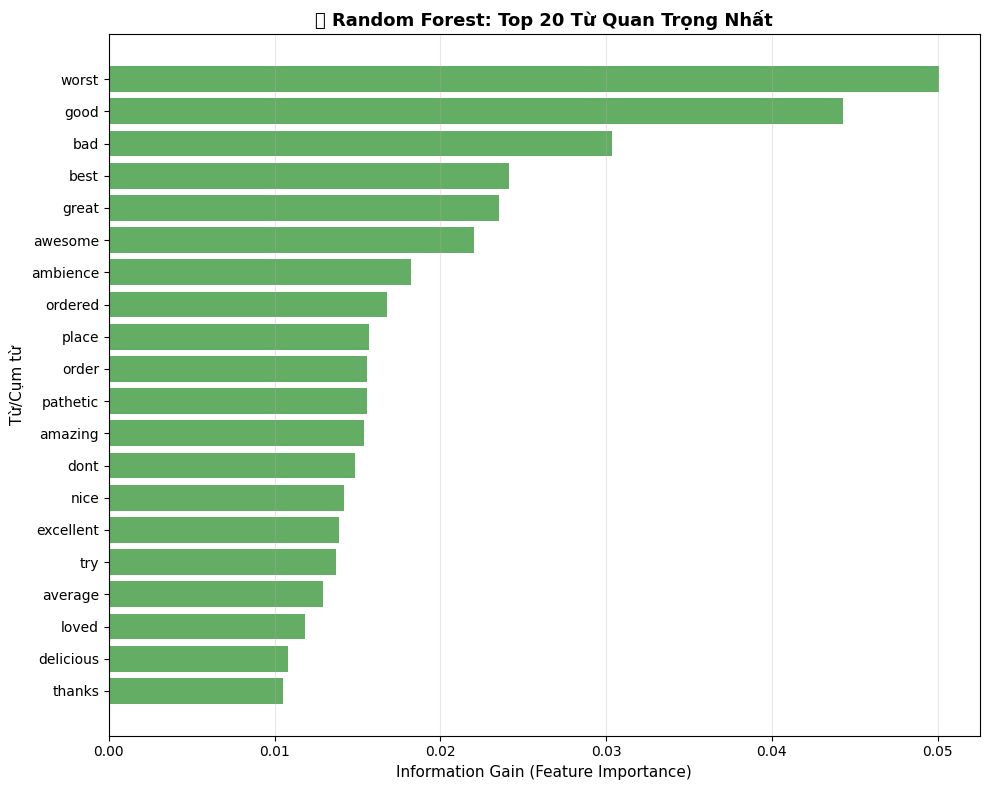


✓ Các từ phía trên có Gain cao nhất → Quan trọng nhất để phân loại rating


In [48]:
# Visualize Top 20 Feature Importance
plt.figure(figsize=(10, 8))

top_20 = importance_df.head(20)
plt.barh(range(len(top_20)), top_20['Importance'], color='forestgreen', alpha=0.7)
plt.yticks(range(len(top_20)), top_20['Feature'])
plt.xlabel('Information Gain (Feature Importance)', fontsize=11)
plt.ylabel('Từ/Cụm từ', fontsize=11)
plt.title('🌲 Random Forest: Top 20 Từ Quan Trọng Nhất', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Các từ phía trên có Gain cao nhất → Quan trọng nhất để phân loại rating")

In [49]:
# Đánh giá trên Test set
print("📊 Random Forest Evaluation - Test Set\n" + "="*50)

y_pred_test = rf_model.predict(X_test)
accuracy_test = accuracy_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test, average='weighted')

print(f"\n✓ Test Accuracy: {accuracy_test*100:.2f}%")
print(f"✓ Test F1 Score (weighted): {f1_test:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_test))

📊 Random Forest Evaluation - Test Set

✓ Test Accuracy: 58.04%
✓ Test F1 Score (weighted): 0.5702

Classification Report:
              precision    recall  f1-score   support

           1       0.60      0.81      0.69       355
           2       0.25      0.20      0.22       146
           3       0.42      0.32      0.36       231
           4       0.49      0.46      0.47       481
           5       0.71      0.71      0.71       751

    accuracy                           0.58      1964
   macro avg       0.49      0.50      0.49      1964
weighted avg       0.57      0.58      0.57      1964



[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


📊 So Sánh Độ Chính Xác: Train vs Test - Random Forest

✓ Train Accuracy: 68.61%
✓ Test Accuracy:  58.04%

✓ Train F1 Score: 0.6838
✓ Test F1 Score:  0.5702

📈 Overfitting Gap: 10.57%
   ⚠️ Model có dấu hiệu overfitting nhẹ


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


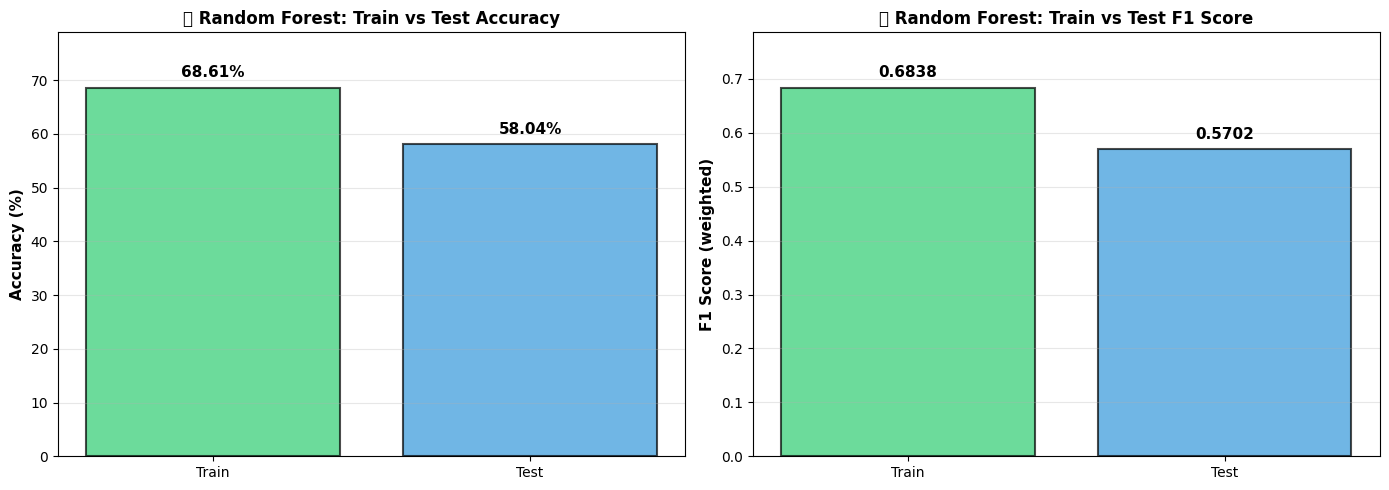

In [50]:
# So sánh độ chính xác trên tập Train và Test
print("📊 So Sánh Độ Chính Xác: Train vs Test - Random Forest\n" + "="*60)

# Predictions trên tập train
y_pred_train = rf_model.predict(X_train)
accuracy_train = accuracy_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train, average='weighted')

print(f"\n✓ Train Accuracy: {accuracy_train*100:.2f}%")
print(f"✓ Test Accuracy:  {accuracy_test*100:.2f}%")
print(f"\n✓ Train F1 Score: {f1_train:.4f}")
print(f"✓ Test F1 Score:  {f1_test:.4f}")

# Tính overfitting gap
overfitting_gap = accuracy_train - accuracy_test
print(f"\n📈 Overfitting Gap: {overfitting_gap*100:.2f}%")
if overfitting_gap < 0.05:
    print("   ✅ Model không bị overfitting nghiêm trọng")
elif overfitting_gap < 0.15:
    print("   ⚠️ Model có dấu hiệu overfitting nhẹ")
else:
    print("   🚨 Model bị overfitting nghiêm trọng!")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart so sánh Accuracy
categories = ['Train', 'Test']
accuracies = [accuracy_train*100, accuracy_test*100]
colors = ['#2ecc71', '#3498db']

bars1 = axes[0].bar(categories, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
axes[0].set_title('🌲 Random Forest: Train vs Test Accuracy', fontsize=12, fontweight='bold')
axes[0].set_ylim([0, max(accuracies) * 1.15])
axes[0].grid(axis='y', alpha=0.3)

for i, (bar, acc) in enumerate(zip(bars1, accuracies)):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(accuracies)*0.02,
                f'{acc:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Bar chart so sánh F1 Score
f1_scores = [f1_train, f1_test]
bars2 = axes[1].bar(categories, f1_scores, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('F1 Score (weighted)', fontsize=11, fontweight='bold')
axes[1].set_title('🌲 Random Forest: Train vs Test F1 Score', fontsize=12, fontweight='bold')
axes[1].set_ylim([0, max(f1_scores) * 1.15])
axes[1].grid(axis='y', alpha=0.3)

for i, (bar, f1) in enumerate(zip(bars2, f1_scores)):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(f1_scores)*0.02,
                f'{f1:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)

## 4.2. Logistic Regression (Softmax)


In [39]:
print("🎯 Training Logistic Regression with Softmax...\n")

# Khởi tạo Logistic Regression với multinomial (softmax)
lr_model = LogisticRegression(
    # multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

# Train model
lr_model.fit(X_train, y_train)

print("\n✓ Logistic Regression training completed!")

🎯 Training Logistic Regression with Softmax...


✓ Logistic Regression training completed!


In [40]:
# Đánh giá Logistic Regression
print("📊 Logistic Regression (Softmax) Evaluation\n" + "="*50)

# Predictions
y_pred_lr = lr_model.predict(X_test)

# Metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')

print(f"\n✓ Accuracy (Tỷ lệ nhất quán): {accuracy_lr*100:.2f}%")
print(f"✓ F1 Score (weighted): {f1_lr:.4f}")
print(f"\n💡 Ý nghĩa: {accuracy_lr*100:.2f}% reviews có text khớp với rating\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

📊 Logistic Regression (Softmax) Evaluation

✓ Accuracy (Tỷ lệ nhất quán): 62.42%
✓ F1 Score (weighted): 0.5883

💡 Ý nghĩa: 62.42% reviews có text khớp với rating

Classification Report:
              precision    recall  f1-score   support

           1       0.69      0.81      0.75       355
           2       0.42      0.03      0.06       146
           3       0.51      0.25      0.33       231
           4       0.49      0.50      0.49       481
           5       0.68      0.85      0.75       751

    accuracy                           0.62      1964
   macro avg       0.56      0.49      0.48      1964
weighted avg       0.60      0.62      0.59      1964



## 4.4. So Sánh Models


In [55]:
# So sánh 2 models
print("📈 So Sánh Khả Năng Phát Hiện Tính Nhất Quán\n" + "="*50 + "\n")

comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression (Softmax)'],
    'Tỷ Lệ Nhất Quán (%)': [accuracy_rf*100, accuracy_lr*100],
    'F1 Score': [f1_rf, f1_lr]
})

print(comparison.to_string(index=False))
print("\n" + "="*50)

# Xác định model tốt nhất
best_model_name = 'Random Forest' if accuracy_rf > accuracy_lr else 'Logistic Regression (Softmax)'
best_accuracy = max(accuracy_rf, accuracy_lr)

print(f"\n🏆 Model Tốt Nhất Để Phát Hiện Fake Reviews: {best_model_name}")
print(f"   Tỷ lệ nhất quán: {best_accuracy*100:.2f}%")
print(f"   → Có thể xác định {(1-best_accuracy)*100:.2f}% reviews nghi ngờ không nhất quán")

📈 So Sánh Khả Năng Phát Hiện Tính Nhất Quán

                        Model  Tỷ Lệ Nhất Quán (%)  F1 Score
                Random Forest            51.985743  0.430499
Logistic Regression (Softmax)            62.423625  0.588310


🏆 Model Tốt Nhất Để Phát Hiện Fake Reviews: Logistic Regression (Softmax)
   Tỷ lệ nhất quán: 62.42%
   → Có thể xác định 37.58% reviews nghi ngờ không nhất quán


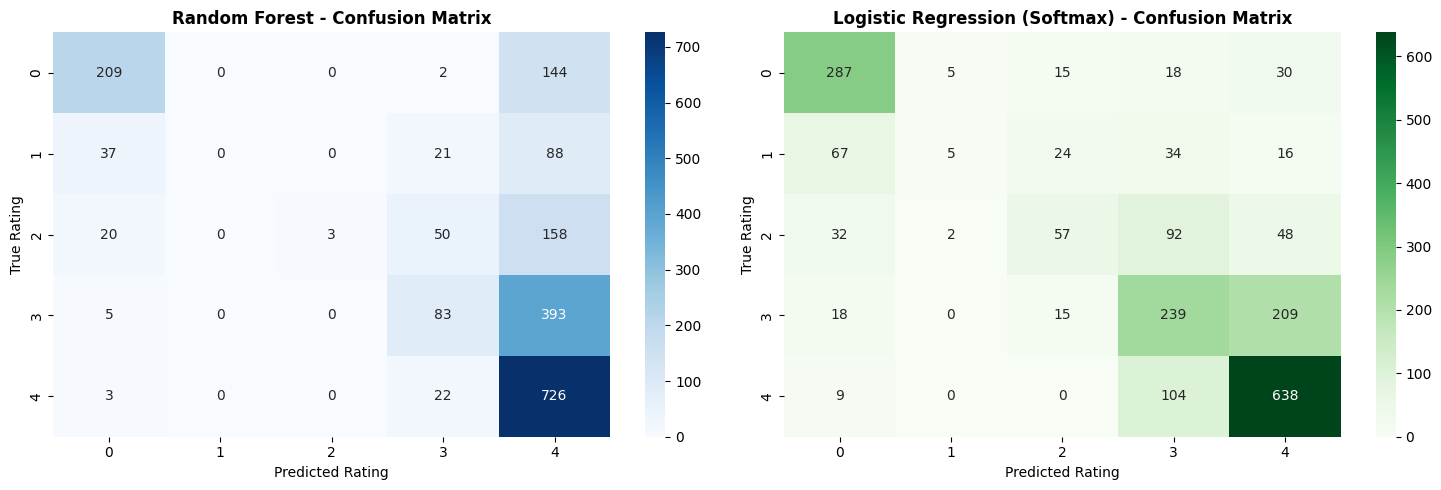

In [56]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=True)
axes[0].set_title('Random Forest - Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Rating')
axes[0].set_ylabel('True Rating')

# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=True)
axes[1].set_title('Logistic Regression (Softmax) - Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Rating')
axes[1].set_ylabel('True Rating')

plt.tight_layout()
plt.show()

## 4.4. Test Với Review Mới (Ví Dụ Không Nhất Quán)


In [54]:
# Test với review không nhất quán vừa thêm vào dataset
print("🧪 TEST VỚI REVIEW KHÔNG NHẤT QUÁN\n")
print("="*70)

# Review mới: Text tiêu cực nhưng rating 5 sao
test_text = "this product doesnt help at all,very poor product, not worth buying"
actual_rating = 5.0

print(f"📝 Text Review: '{test_text}'")
print(f"⭐ Rating Thực Tế: {actual_rating} sao")
print("\n" + "="*70)

# Preprocess text
text_clean = clean_text(test_text)
text_tfidf = tfidf_vectorizer.transform([text_clean])

# Predict với Random Forest
pred_rf = rf_model.predict(text_tfidf)[0]
prob_rf = rf_model.predict_proba(text_tfidf)[0]

print(f"\n🌲 RANDOM FOREST:")
print(f"   Predicted Rating: {pred_rf} sao")
print(f"   Chênh lệch: {abs(pred_rf - actual_rating)} sao")
print(f"   Kết luận: {'✅ NHẤT QUÁN' if pred_rf == actual_rating else '🚨 KHÔNG NHẤT QUÁN - NGHI NGỜ FAKE'}")
print(f"\n   Xác suất dự đoán:")
for i, prob in enumerate(prob_rf, start=1):
    bar = '█' * int(prob * 30)
    print(f"      {i} sao: {bar} {prob*100:.2f}%")

# Predict với Logistic Regression
pred_lr = lr_model.predict(text_tfidf)[0]
prob_lr = lr_model.predict_proba(text_tfidf)[0]

print(f"\n🎯 LOGISTIC REGRESSION:")
print(f"   Predicted Rating: {pred_lr} sao")
print(f"   Chênh lệch: {abs(pred_lr - actual_rating)} sao")
print(f"   Kết luận: {'✅ NHẤT QUÁN' if pred_lr == actual_rating else '🚨 KHÔNG NHẤT QUÁN - NGHI NGỜ FAKE'}")
print(f"\n   Xác suất dự đoán:")
for i, prob in enumerate(prob_lr, start=1):
    bar = '█' * int(prob * 30)
    print(f"      {i} sao: {bar} {prob*100:.2f}%")

print("\n" + "="*70)
print("\n💡 PHÂN TÍCH:")
print("   Text chứa từ 'bad', 'poor', 'not worth' → Sentiment tiêu cực")
print("   Models dự đoán rating thấp (1-2 sao)")
print("   Nhưng rating thực tế: 5 sao")
print("   → Review này RẤT NGHI NGỜ - Có khả năng là FAKE!")

🧪 TEST VỚI REVIEW KHÔNG NHẤT QUÁN

📝 Text Review: 'this product doesnt help at all,very poor product, not worth buying'
⭐ Rating Thực Tế: 5.0 sao


🌲 RANDOM FOREST:
   Predicted Rating: 1 sao
   Chênh lệch: 4.0 sao
   Kết luận: 🚨 KHÔNG NHẤT QUÁN - NGHI NGỜ FAKE

   Xác suất dự đoán:
      1 sao: ███████ 25.17%
      2 sao: ██████ 22.96%
      3 sao: █████ 19.11%
      4 sao: ████ 14.78%
      5 sao: █████ 17.98%

🎯 LOGISTIC REGRESSION:
   Predicted Rating: 1 sao
   Chênh lệch: 4.0 sao
   Kết luận: 🚨 KHÔNG NHẤT QUÁN - NGHI NGỜ FAKE

   Xác suất dự đoán:
      1 sao: ██████████████ 49.78%
      2 sao: ██ 9.93%
      3 sao: ███ 12.50%
      4 sao: ██ 7.26%
      5 sao: ██████ 20.52%


💡 PHÂN TÍCH:
   Text chứa từ 'bad', 'poor', 'not worth' → Sentiment tiêu cực
   Models dự đoán rating thấp (1-2 sao)
   Nhưng rating thực tế: 5 sao
   → Review này RẤT NGHI NGỜ - Có khả năng là FAKE!


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


## 4.5. Naive Bayes


In [28]:
print("🎯 Training Naive Bayes (Multinomial)...\n")

# Khởi tạo Naive Bayes
nb_model = MultinomialNB(
    alpha=0.5   # smoothing, có thể thử 0.1–1.0
)

# Train model
nb_model.fit(X_train, y_train)

print("\n✓ Naive Bayes training completed!")


🎯 Training Naive Bayes (Multinomial)...


✓ Naive Bayes training completed!


📊 So Sánh Độ Chính Xác: Train vs Test - Naive Bayes

✓ Train Accuracy: 72.60%
✓ Test Accuracy:  62.42%

✓ Train F1 Score: 0.6948
✓ Test F1 Score:  0.5797

📈 Overfitting Gap: 10.17%
   ⚠️ Model có dấu hiệu overfitting nhẹ


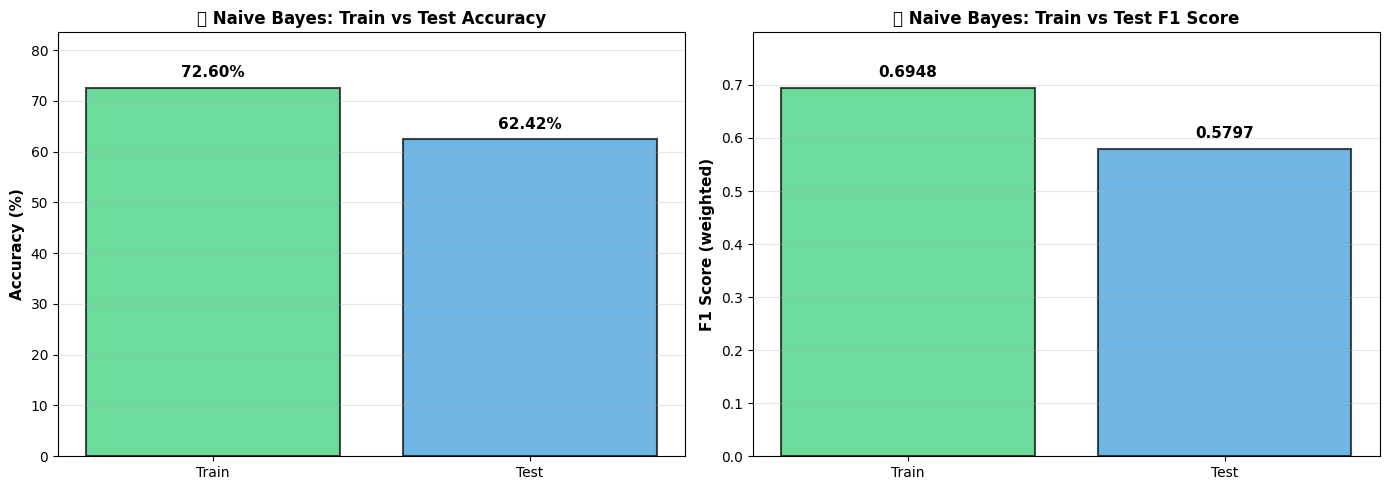

In [44]:
# ===============================
# So sánh Train vs Test - Naive Bayes
# ===============================

print("📊 So Sánh Độ Chính Xác: Train vs Test - Naive Bayes\n" + "="*60)

# Predictions
y_pred_train_nb = nb_model.predict(X_train)
y_pred_test_nb  = nb_model.predict(X_test)

# Metrics
accuracy_train_nb = accuracy_score(y_train, y_pred_train_nb)
accuracy_test_nb  = accuracy_score(y_test, y_pred_test_nb)

f1_train_nb = f1_score(y_train, y_pred_train_nb, average='weighted')
f1_test_nb  = f1_score(y_test, y_pred_test_nb, average='weighted')

print(f"\n✓ Train Accuracy: {accuracy_train_nb*100:.2f}%")
print(f"✓ Test Accuracy:  {accuracy_test_nb*100:.2f}%")
print(f"\n✓ Train F1 Score: {f1_train_nb:.4f}")
print(f"✓ Test F1 Score:  {f1_test_nb:.4f}")

# Overfitting gap
overfitting_gap = accuracy_train_nb - accuracy_test_nb
print(f"\n📈 Overfitting Gap: {overfitting_gap*100:.2f}%")

if overfitting_gap < 0.05:
    print("   ✅ Model không bị overfitting nghiêm trọng")
elif overfitting_gap < 0.15:
    print("   ⚠️ Model có dấu hiệu overfitting nhẹ")
else:
    print("   🚨 Model bị overfitting nghiêm trọng!")

# ===============================
# Visualization
# ===============================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

categories = ['Train', 'Test']
colors = ['#2ecc71', '#3498db']

# Accuracy bar chart
accuracies = [accuracy_train_nb*100, accuracy_test_nb*100]
bars1 = axes[0].bar(categories, accuracies, color=colors, alpha=0.7,
                    edgecolor='black', linewidth=1.5)

axes[0].set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
axes[0].set_title('📘 Naive Bayes: Train vs Test Accuracy',
                  fontsize=12, fontweight='bold')
axes[0].set_ylim([0, max(accuracies) * 1.15])
axes[0].grid(axis='y', alpha=0.3)

for bar, acc in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max(accuracies)*0.02,
                 f'{acc:.2f}%',
                 ha='center', va='bottom',
                 fontsize=11, fontweight='bold')

# F1 bar chart
f1_scores = [f1_train_nb, f1_test_nb]
bars2 = axes[1].bar(categories, f1_scores, color=colors, alpha=0.7,
                    edgecolor='black', linewidth=1.5)

axes[1].set_ylabel('F1 Score (weighted)', fontsize=11, fontweight='bold')
axes[1].set_title('📘 Naive Bayes: Train vs Test F1 Score',
                  fontsize=12, fontweight='bold')
axes[1].set_ylim([0, max(f1_scores) * 1.15])
axes[1].grid(axis='y', alpha=0.3)

for bar, f1 in zip(bars2, f1_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max(f1_scores)*0.02,
                 f'{f1:.4f}',
                 ha='center', va='bottom',
                 fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
